In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [4]:
dfi=pd.read_csv('RECLAMEAQUI_IBYTE.csv')
dfi.head()

,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS
0,21898349,Quebraram a tela do meu Notebook,Hidrolândia - CE,2016-02-11,Ibyte - Loja Física<->Informática,Resolvido,Em 05/10/2016 deixei meu Notebook para consert...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,2,11,42,6,3,1,1
1,22581481,Solicitação de Cancelamento de Compra,Araxá - MG,2016-03-12,Não consigo fazer operação por telefone<->Cana...,Em réplica,"Prezados, efetuei uma compra no site www.ameri...",https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,3,12,72,10,5,1,2
2,22579385,Inutilizarão a tela do meu notebook,Fortaleza - CE,2016-03-12,Problemas na Loja<->Ibyte - Loja Física<->Prod...,Respondida,Decidi conserta meu notebook que parou de inic...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,3,12,72,10,5,1,2
3,21328791,Produto não faz o que vendedor informa!,Fortaleza - CE,2016-04-10,Ibyte - Loja Física<->Impressoras<->Produto er...,Em réplica,Venho através desde canal de reclamação expor ...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,4,10,101,14,6,2,1
4,22608043,Ibyte não troca o produto,Fortaleza - CE,2016-05-12,Smartphone<->Celulares e Smartphones<->Blackfr...,Respondida,Comprei um celular na black Friday e com 4 dia...,https://www.reclameaqui.com.br//ibyte-loja-fis...,2016,5,12,133,19,3,2,2


In [6]:
categorias=[]
lixo='Ibyte - Loja Física'
for i in range(len(dfi)):
    categorias=categorias+dfi.CATEGORIA.iloc[i].split('<->')

dc=pd.DataFrame({'CATEGORIA':categorias})
dc=dc[dc.CATEGORIA!=lixo]
dc.CATEGORIA.value_counts()

CATEGORIA
Informática                                          337
Acessórios para Celulares, Tablets e Computadores    153
Outro Tipo de produto/Serviço                        115
Eletroeletrônicos                                    108
Produto com defeito                                  107
                                                    ... 
Fila                                                   1
Qualidade da impressão                                 1
Demora para carregar                                   1
Problemas com as ligações                              1
Máquina fotográfica                                    1
Name: count, Length: 130, dtype: int64

In [7]:
categorias=[]
for i in range(len(dfi)):
    lista=list(dfi.CATEGORIA.iloc[i].split('<->'))
    lista.remove(lixo)
    categorias.append(lista)

In [8]:
dfi['CATEGORIA_LISTA']=categorias

In [9]:
dfi['LEN_CAT']=dfi.CATEGORIA_LISTA.apply(len)

In [10]:
d1=dfi[dfi['LEN_CAT']>1].reset_index(drop=True)

In [11]:
nn=len(dc.CATEGORIA.unique())
cateones=list(dc.CATEGORIA.unique())
matriz=np.zeros((nn,nn))

In [12]:
categorias=[]
for i in range(len(d1)):
    lista=list(d1.CATEGORIA.iloc[i].split('<->'))
    lista.remove(lixo)
    for i in range(len(lista)-1):
        for j in range(i+1,len(lista)):

            ii=cateones.index(lista[i])
            jj=cateones.index(lista[j])
            matriz[ii,jj]=matriz[ii,jj]+1
            matriz[jj,ii]=matriz[jj,ii]+1

matrix_normalizada = matriz / matriz.sum(axis=1, keepdims=True)


<ipython-input-12-b2578b6917c5>:13: RuntimeWarning: invalid value encountered in divide
  matrix_normalizada = matriz / matriz.sum(axis=1, keepdims=True)


In [13]:
dboll=pd.DataFrame(data=matriz,index=cateones,columns=cateones)
dboll_normalizada=pd.DataFrame(data=matrix_normalizada,index=cateones,columns=cateones)

In [14]:
dboll_normalizada

,Informática,Não consigo fazer operação por telefone,Canais de Atendimento,Problemas com o Atendimento,Problemas na Loja,Produto danificado,Entrega,Impressoras,Produto errado,Smartphone,...,Corrompido,Não reconhece USB,Controle remoto,Incompatível com o aparelho,Troca-Devolução de produto,Máquinas fotográficas-Filmadoras,Álbum de fotos,Não protegeu a tela,Películas para tela,Máquina fotográfica
Informática,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031142,0.029412,0.0,...,0.0,0.00173,0.0,0.0,0.00173,0.0,0.0,0.0,0.0,0.0
Não consigo fazer operação por telefone,0.0,0.000000,0.500000,0.5,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
Canais de Atendimento,0.0,0.214286,0.000000,0.5,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
Problemas com o Atendimento,0.0,0.036585,0.085366,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
Problemas na Loja,0.0,0.000000,0.000000,0.0,0.0,0.026316,0.131579,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Máquinas fotográficas-Filmadoras,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
Álbum de fotos,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0
Não protegeu a tela,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.0,0.5,0.0
Películas para tela,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.00000,0.0,0.0,0.00000,0.0,0.0,0.5,0.0,0.0


In [16]:
# verificando as categorias mais frequentes
top_categorias=dboll.sum(axis=1).sort_values(ascending=False).index[0:10]
top_categorias

Index(['Informática', 'Acessórios para Celulares, Tablets e Computadores',
       'Produto com defeito', 'Eletroeletrônicos',
       'Outro Tipo de produto/Serviço', 'Notebooks',
       'Componentes, peças e acessórios', 'Mau Atendimento',
       'Celulares e Smartphones', 'Outro problema'],
      dtype='object')

Text(0.5, 60.66666666666666, 'MELHOR CO-OCORRENCIA')

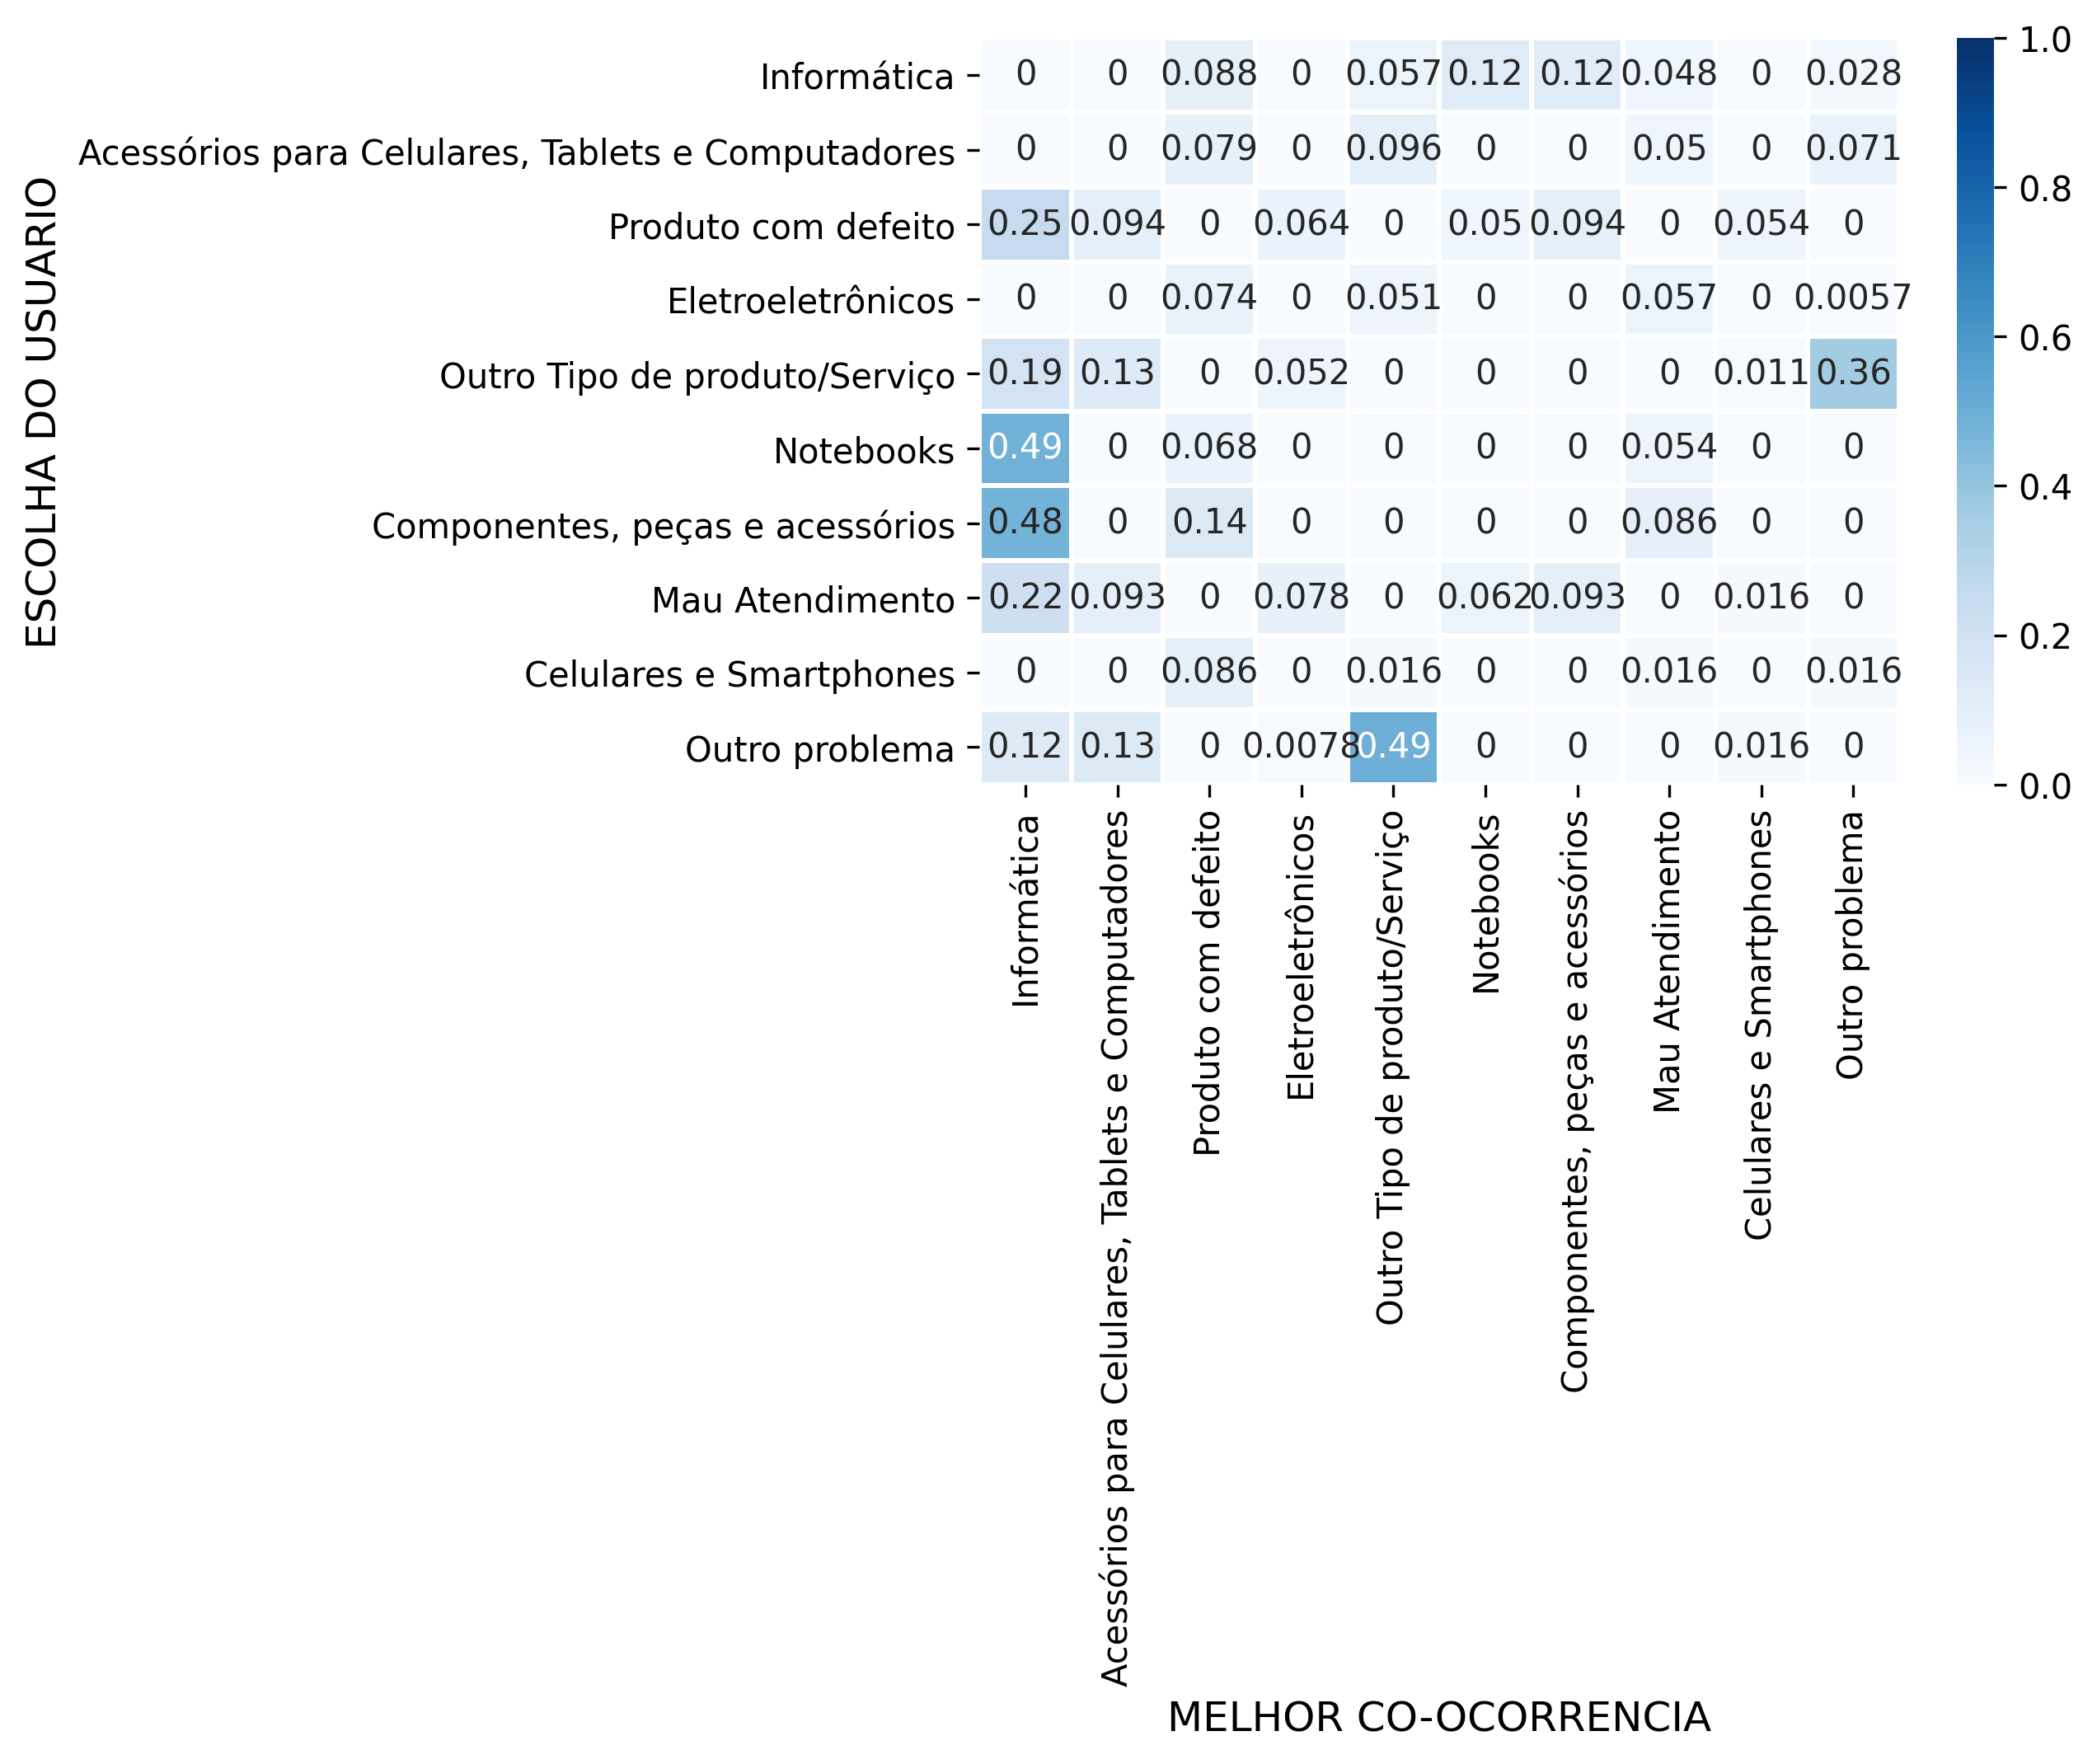

In [17]:
plt.figure(dpi=300)
sns.heatmap(dboll_normalizada[top_categorias].loc[top_categorias],annot=True,cmap='Blues',lw=1,annot_kws={"size":10},vmin=0,vmax=1)
plt.ylabel('ESCOLHA DO USUARIO',fontsize=12)
plt.xlabel('MELHOR CO-OCORRENCIA',fontsize=12)

In [19]:
# Criando uma inferencia:'Componentes, peças e acessórios'
dboll_normalizada.loc['Componentes, peças e acessórios'].sort_values()

Assistência técnica indisponível         0.000000
Não atende                               0.000000
Home Theater                             0.000000
Problema para sintonizar rádios AM-FM    0.000000
Não se conecta à internet                0.000000
                                           ...   
Produto errado                           0.050000
Estorno do valor pago                    0.071429
Mau Atendimento                          0.085714
Produto com defeito                      0.135714
Informática                              0.478571
Name: Componentes, peças e acessórios, Length: 130, dtype: float64